<a href="https://colab.research.google.com/github/ayushman-c/kaggle-notebooks/blob/main/Linear_Reegression/MLR_5_dimensions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv('/content/CarPrice_Assignment.csv')

Predicting Price is the primary Objective

Since our primary objective is to predict car price, let's identify the features that are most correlated with the `price` column and visualize only those.

In [6]:
correlations_with_price = df.corr(numeric_only=True)['price'].sort_values(ascending=False)
print('Correlations with Price:')
display(correlations_with_price)


Correlations with Price:


,price
price,1.000000
enginesize,0.874145
curbweight,0.835305
horsepower,0.808139
carwidth,0.759325
carlength,0.682920
wheelbase,0.577816
boreratio,0.553173
carheight,0.119336
stroke,0.079443


Let's select the top 10 most positively and negatively correlated features with `price` (excluding `price` itself) to create a more focused heatmap.

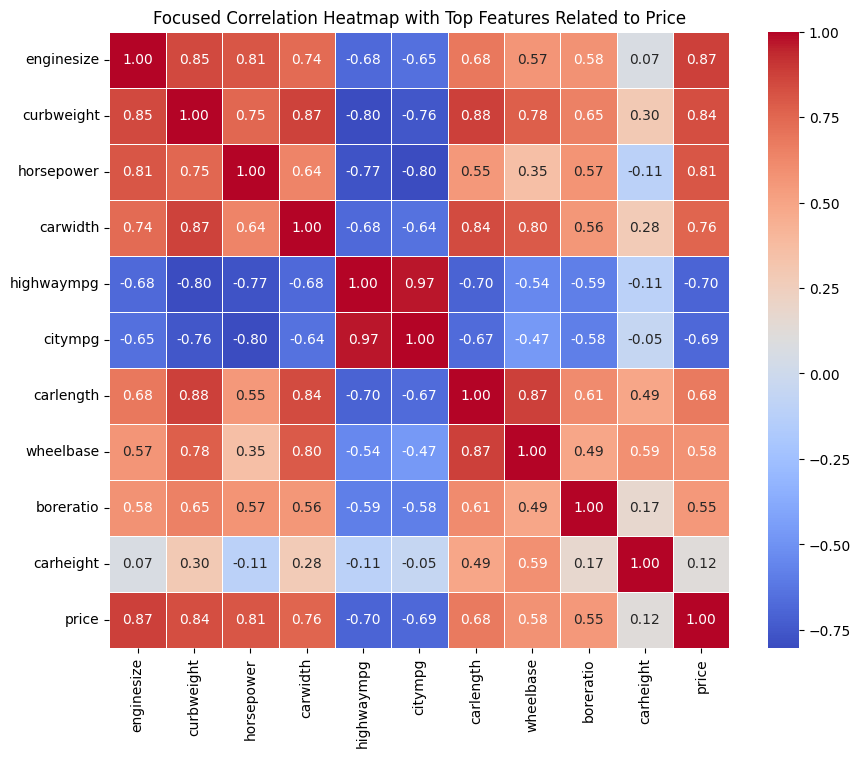

In [7]:
top_correlated_features = correlations_with_price.abs().nlargest(11).index.tolist() # Get top 11 including 'price'
if 'price' in top_correlated_features:
    top_correlated_features.remove('price') # Remove 'price' itself to avoid self-correlation

# Include 'price' back in for the heatmap if not already present
if 'price' not in top_correlated_features:
    top_correlated_features.append('price')

# Create a new correlation matrix with only the selected features
focused_corr = df[top_correlated_features].corr(numeric_only=True)

# Plot the new, more focused heatmap
plt.figure(figsize=(10, 8)) # Adjust figure size for better visibility
sns.heatmap(focused_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Focused Correlation Heatmap with Top Features Related to Price')
plt.show()


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [4]:
df.head(5)

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [14]:
new_df = df[['enginesize','curbweight','horsepower','carwidth','carlength','price']]

In [16]:
print(new_df.head())

   enginesize  curbweight  horsepower  carwidth  carlength    price
0         130        2548         111      64.1      168.8  13495.0
1         130        2548         111      64.1      168.8  16500.0
2         152        2823         154      65.5      171.2  16500.0
3         109        2337         102      66.2      176.6  13950.0
4         136        2824         115      66.4      176.6  17450.0


In [20]:
X,y = new_df.iloc[:,:-1],new_df.iloc[:,-1]

print(X)
print(y)

     enginesize  curbweight  horsepower  carwidth  carlength
0           130        2548         111      64.1      168.8
1           130        2548         111      64.1      168.8
2           152        2823         154      65.5      171.2
3           109        2337         102      66.2      176.6
4           136        2824         115      66.4      176.6
..          ...         ...         ...       ...        ...
200         141        2952         114      68.9      188.8
201         141        3049         160      68.8      188.8
202         173        3012         134      68.9      188.8
203         145        3217         106      68.9      188.8
204         141        3062         114      68.9      188.8

[205 rows x 5 columns]
0      13495.0
1      16500.0
2      16500.0
3      13950.0
4      17450.0
        ...   
200    16845.0
201    19045.0
202    21485.0
203    22470.0
204    22625.0
Name: price, Length: 205, dtype: float64


In [21]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=3)

In [22]:
print(X_train.shape)
print(X_test.shape)

(164, 5)
(41, 5)


In [24]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)


LinearRegression()

In [25]:
y_pred = lr.predict(X_test)

In [26]:
print(mean_absolute_error(y_test, y_pred))
print(mean_squared_error(y_test, y_pred))
print(r2_score(y_test,y_pred))

2416.8739294756733
11450152.478939692
0.8614061268176239
